![](https://t4.ftcdn.net/jpg/04/60/05/05/360_F_460050532_7JjxeTTaZLyk7RTOayql8iX4O6Zlctjs.jpg)

#### This year is the year of the black tiger. happy New Year.
#### (올해는 흑호의 해입니다. 새해 복 많이 받으세요.)

#### Create a model using the following library.: (다음 라이브러리를 사용하여 모델을 생성했다.:)
#### ● Pycaret (파이캐롯)

In [1]:
# Code Sorce : https://www.kaggle.com/bernhardklinger/tps-jan-2022
!pip install pycaret[full]

     |████████████████████████████████| 301 kB 925 kB/s            
     |████████████████████████████████| 10.4 MB 9.6 MB/s            
     |████████████████████████████████| 114 kB 48.0 MB/s            
  Preparing metadata (setup.py) ... - done
     |████████████████████████████████| 636 kB 52.7 MB/s            
     |████████████████████████████████| 15.6 MB 50.4 MB/s            
     |████████████████████████████████| 167 kB 60.3 MB/s            
     |████████████████████████████████| 25.9 MB 58.6 MB/s            
     |████████████████████████████████| 24.2 MB 23.1 MB/s            
     |████████████████████████████████| 13.3 MB 18.1 MB/s            
     |████████████████████████████████| 865 kB 42.5 MB/s            
     |████████████████████████████████| 356 kB 58.1 MB/s            
     |████████████████████████████████| 59 kB 4.9 MB/s             
     |████████████████████████████████| 177 kB 59.8 MB/s            
     |████████████████████████████████| 40 kB 4.4 MB/s  

# Loading Data (데이터 불러오기)

In [2]:
# Code Sorce : https://www.kaggle.com/bernhardklinger/tps-jan-2022
import pandas as pd
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.regression import *
from sklearn.datasets import make_classification
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

data = pd.read_csv('/kaggle/input/tabular-playground-series-jan-2022/train.csv')

train = pd.read_csv('../input/tabular-playground-series-jan-2022/train.csv',index_col='row_id')
test = pd.read_csv('../input/tabular-playground-series-jan-2022/test.csv',index_col='row_id')

#### ▶ This is the code to check the total file size.
####   If you put 'train' and 'test' in '( )', you can check the capacity of each.
####   (전체 파일 용량을 확인하는 코드이다. '( )' 안에 'train'과 'test'를 넣으면 각각의 용량도 확인할 수 있다.)

In [3]:
def mem_usage(pandas_obj):
    if isinstance(pandas_obj,pd.DataFrame):
        usage_b = pandas_obj.memory_usage(deep=True).sum()
    else: # we assume if not a df it's a series
        usage_b = pandas_obj.memory_usage(deep=True)
    usage_mb = usage_b / 1024 ** 2 # convert bytes to megabytes
    return "{:03.2f} MB".format(usage_mb)

In [4]:
mem_usage(train)

'7.06 MB'

In [5]:
mem_usage(test)

'1.71 MB'

In [6]:
train.head()

,date,country,store,product,num_sold
row_id,,,,,
0,2015-01-01,Finland,KaggleMart,Kaggle Mug,329
1,2015-01-01,Finland,KaggleMart,Kaggle Hat,520
2,2015-01-01,Finland,KaggleMart,Kaggle Sticker,146
3,2015-01-01,Finland,KaggleRama,Kaggle Mug,572
4,2015-01-01,Finland,KaggleRama,Kaggle Hat,911


In [7]:
test.head()

,date,country,store,product
row_id,,,,
26298,2019-01-01,Finland,KaggleMart,Kaggle Mug
26299,2019-01-01,Finland,KaggleMart,Kaggle Hat
26300,2019-01-01,Finland,KaggleMart,Kaggle Sticker
26301,2019-01-01,Finland,KaggleRama,Kaggle Mug
26302,2019-01-01,Finland,KaggleRama,Kaggle Hat


In [8]:
data.head().style.applymap(lambda x : "background-color: #bff9ff")\
.set_table_styles([{'selector' : '', 'props' : [('border', '2px solid black')]}])

,row_id,date,country,store,product,num_sold
0,0,2015-01-01,Finland,KaggleMart,Kaggle Mug,329
1,1,2015-01-01,Finland,KaggleMart,Kaggle Hat,520
2,2,2015-01-01,Finland,KaggleMart,Kaggle Sticker,146
3,3,2015-01-01,Finland,KaggleRama,Kaggle Mug,572
4,4,2015-01-01,Finland,KaggleRama,Kaggle Hat,911


In [9]:
data = data.drop('row_id', axis=1)
data.head()

data.date = pd.to_datetime(data.date)
data.date.dtype

dtype('<M8[ns]')

In [10]:
prop = pd.DataFrame(data.groupby('product')['num_sold'].sum()).reset_index()

prop.num_sold = prop.num_sold/prop.num_sold.sum()
prop.style.applymap(lambda x : "background-color: #bff9ff")\
.set_table_styles([{'selector' : '', 'props' : [('border', '2px solid black')]}])

,product,num_sold
0,Kaggle Hat,0.540896
1,Kaggle Mug,0.304796
2,Kaggle Sticker,0.154308


In [11]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
train.describe

<bound method NDFrame.describe of               date  country       store         product  num_sold
row_id                                                           
0       2015-01-01  Finland  KaggleMart      Kaggle Mug       329
1       2015-01-01  Finland  KaggleMart      Kaggle Hat       520
2       2015-01-01  Finland  KaggleMart  Kaggle Sticker       146
3       2015-01-01  Finland  KaggleRama      Kaggle Mug       572
4       2015-01-01  Finland  KaggleRama      Kaggle Hat       911
...            ...      ...         ...             ...       ...
26293   2018-12-31   Sweden  KaggleMart      Kaggle Hat       823
26294   2018-12-31   Sweden  KaggleMart  Kaggle Sticker       250
26295   2018-12-31   Sweden  KaggleRama      Kaggle Mug      1004
26296   2018-12-31   Sweden  KaggleRama      Kaggle Hat      1441
26297   2018-12-31   Sweden  KaggleRama  Kaggle Sticker       388

[26298 rows x 5 columns]>

In [12]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
for col in ['country', 'store', 'product']:
    print(col, train[col].unique())

country ['Finland' 'Norway' 'Sweden']
store ['KaggleMart' 'KaggleRama']
product ['Kaggle Mug' 'Kaggle Hat' 'Kaggle Sticker']


In [13]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
print('train date duration : ', train['date'].min(), train['date'].max())
print('test date duration : ', test['date'].min(), test['date'].max())

train date duration :  2015-01-01 2018-12-31
test date duration :  2019-01-01 2019-12-31


#### Train dataset is data for 3 years from 2015 to 2018, and test dataset is data for 1 year from 2019.
#### (Train 데이터셋은 2015년부터 2018년까지 3년간의 데이터이고, 테스트 데이터셋은 2019년부터 1년간의 데이터입니다.)

In [14]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
for col in ['country', 'store', 'product']:
    display(pd.DataFrame(train[col].value_counts()))

,country
Finland,8766
Norway,8766
Sweden,8766


,store
KaggleMart,13149
KaggleRama,13149


,product
Kaggle Mug,8766
Kaggle Hat,8766
Kaggle Sticker,8766


In [15]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
for col in ['country', 'store', 'product']:
    display(pd.DataFrame(test[col].value_counts()))

,country
Finland,2190
Norway,2190
Sweden,2190


,store
KaggleMart,3285
KaggleRama,3285


,product
Kaggle Mug,2190
Kaggle Hat,2190
Kaggle Sticker,2190


In [16]:
train.isnull().sum()

date        0
country     0
store       0
product     0
num_sold    0
dtype: int64

In [17]:
test.isnull().sum()

date       0
country    0
store      0
product    0
dtype: int64

In [18]:
train.isna().sum()

date        0
country     0
store       0
product     0
num_sold    0
dtype: int64

In [19]:
test.isna().sum()

date       0
country    0
store      0
product    0
dtype: int64

# Preprocessing & Visualization (전처리와 시각화)
#### Time series data needs to be preprocessed for data analysis, feature engineering, visualization, etc.
#### (시계열 데이터는 데이터 분석, 피쳐 엔지니어링, 시각화 등을 위해 전처리해야 합니다.)

#### ▶ The date column type is text. Convert to datetime type for easy handling in pandas. 
#### (날짜 열 유형은 텍스트입니다. pandas에서 쉽게 처리할 수 있도록 datetime형으로 변환합니다.)

In [20]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
train['date'] = pd.to_datetime(train['date'])
test['date'] = pd.to_datetime(test['date'])

#### Pivot Table (time) (피벗 테이블(시간))
#### ▶ by date (날짜 별)

In [21]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
train_date = train.set_index('date').pivot(columns=['country', 'store', 'product'], values='num_sold')
train_date.head()

country       Finland                                                  \
store      KaggleMart                           KaggleRama              
product    Kaggle Mug Kaggle Hat Kaggle Sticker Kaggle Mug Kaggle Hat   
date                                                                    
2015-01-01        329        520            146        572        911   
2015-01-02        318        493            127        544        794   
2015-01-03        360        535            141        579        843   
2015-01-04        332        544            125        582        873   
2015-01-05        243        378            102        423        668   

country                       Norway                                       \
store                     KaggleMart                           KaggleRama   
product    Kaggle Sticker Kaggle Mug Kaggle Hat Kaggle Sticker Kaggle Mug   
date                                                                        
2015-01-01            283        526        906            250       1005   
2015-01-02            249        538        845            237        949   
2015-01-03            265        614        930            254       1029   
2015-01-04            245        589        889            255        957   
2015-01-05            187        435        671            184        739   

country                                  Sweden                            \
store                                KaggleMart                             
product    Kaggle Hat Kaggle Sticker Kaggle Mug Kaggle Hat Kaggle Sticker   
date                                                                        
2015-01-01       1461            395        440        624            175   
2015-01-02       1446            415        384        572            155   
2015-01-03       1631            451        420        630            173   
2015-01-04       1540            455        406        697            169   
2015-01-05       1126            310        298        442            127   

country                                          
store      KaggleRama                            
product    Kaggle Mug Kaggle Hat Kaggle Sticker  
date                                             
2015-01-01        706       1195            324  
2015-01-02        653        986            293  
2015-01-03        734       1167            319  
2015-01-04        657       1112            300  
2015-01-05        512        796            227

#### ▶ by month (월 별)
#### ▶ For grouping by month, I recommend using pandas' latest feature grouper.
####   (월 별 그룹화는 pandas의 최신 기능 그룹화를 사용하는 것이 좋습니다.)

In [22]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
train_month = train.set_index('date').groupby([pd.Grouper(freq='M'), 'country', 'store', 'product'])['num_sold'].mean().unstack([1, 2, 3])
train_month_country = train.set_index('date').groupby([pd.Grouper(freq='M'), 'country'])['num_sold'].mean().unstack()
train_month.head()

country        Finland                                                     \
store       KaggleMart                             KaggleRama               
product     Kaggle Hat  Kaggle Mug Kaggle Sticker  Kaggle Hat  Kaggle Mug   
date                                                                        
2015-01-31  367.612903  221.193548      97.096774  623.967742  388.903226   
2015-02-28  362.928571  193.535714      88.928571  632.857143  341.785714   
2015-03-31  383.774194  185.967742      90.290323  663.516129  324.387097   
2015-04-30  407.800000  184.633333      95.666667  704.733333  317.800000   
2015-05-31  392.387097  171.709677      96.709677  691.290323  299.000000   

country                        Norway                                          \
store                      KaggleMart                              KaggleRama   
product    Kaggle Sticker  Kaggle Hat  Kaggle Mug Kaggle Sticker   Kaggle Hat   
date                                                                            
2015-01-31     172.129032  613.451613  382.645161     167.516129  1074.225806   
2015-02-28     154.178571  623.321429  338.857143     154.928571  1096.964286   
2015-03-31     156.419355  656.096774  322.548387     157.096774  1165.290323   
2015-04-30     167.466667  736.266667  329.000000     168.333333  1254.666667   
2015-05-31     169.806452  718.225806  312.096774     178.903226  1249.000000   

country                                    Sweden                             \
store                                  KaggleMart                              
product     Kaggle Mug Kaggle Sticker  Kaggle Hat  Kaggle Mug Kaggle Sticker   
date                                                                           
2015-01-31  650.419355     290.419355  436.290323  269.516129     119.032258   
2015-02-28  587.535714     269.750000  441.107143  239.142857     108.821429   
2015-03-31  555.419355     272.193548  455.580645  224.096774     107.225806   
2015-04-30  569.300000     295.933333  491.500000  216.633333     114.400000   
2015-05-31  547.903226     303.548387  473.838710  206.451613     117.838710   

country                                            
store       KaggleRama                             
product     Kaggle Hat  Kaggle Mug Kaggle Sticker  
date                                               
2015-01-31  769.387097  470.096774     204.064516  
2015-02-28  749.714286  408.642857     191.607143  
2015-03-31  800.612903  397.129032     189.322581  
2015-04-30  853.966667  379.200000     198.633333  
2015-05-31  827.709677  359.354839     205.387097

In [23]:
norway  = data[data.country == 'Norway']
norway  = pd.DataFrame(norway.groupby('product')['num_sold'].sum()).reset_index()

finland = data[data.country == 'Finland']
finland = pd.DataFrame(finland.groupby('product')['num_sold'].sum()).reset_index()

sweden  = data[data.country == 'Sweden']
sweden  = pd.DataFrame(sweden.groupby('product')['num_sold'].sum()).reset_index()

In [24]:
fig = make_subplots(rows=3, cols=1,
                    specs=[[{'type':'domain'}],[{'type':'domain'}],[{'type':'domain'}]],
                    vertical_spacing = 0.1)

fig.add_trace(go.Pie(
             values = norway['num_sold'],
             labels = norway['product'],
             title = dict(text = 'Distribution of<br>Kaggle Products<br>sales in Norway',
                          font = dict(size=18, family = 'monospace'),
                          ),
             hole = 0.5,
             hoverinfo='label+percent',),1,1)

fig.add_trace(go.Pie(
             values = finland['num_sold'],
             labels = finland['product'],
             title = dict(text = 'Distribution of<br>Kaggle Products<br>sales in Finland',
                          font = dict(size=18, family = 'monospace'),
                          ),
             hole = 0.5,
             hoverinfo='label+percent',),2,1)

fig.add_trace(go.Pie(
             values = sweden['num_sold'],
             labels = sweden['product'],
             title = dict(text = 'Distribution of<br>Kaggle Products<br>sales in Sweden',
                          font = dict(size=18, family = 'monospace'),
                          ),
             hole = 0.5,
             hoverinfo='label+percent',),3,1)

fig.update_traces(row=1, col=1, hoverinfo='label+percent',
                  textinfo='label+percent',
                  textfont_size=12,
                  opacity = 0.8,
                  showlegend = False,
                  marker = dict(colors = sns.color_palette('Reds').as_hex(),
                              line=dict(color='#000000', width=1)))

fig.update_traces(row=2, col=1, hoverinfo='label+percent',
                  textinfo='label+percent',
                  textfont_size=12,
                  opacity = 0.8,
                  showlegend = False,
                  marker = dict(colors = sns.color_palette('Blues').as_hex(),
                              line=dict(color='#000000', width=1)))

fig.update_traces(row=3, col=1, hoverinfo='label+percent',
                  textinfo='label+percent',
                  textfont_size=12,
                  opacity = 0.8,
                  showlegend = False,
                  marker = dict(colors = sns.color_palette('Wistia').as_hex(),
                              line=dict(color='#000000', width=1)))

fig.add_layout_image(
    dict(
        source="https://i.postimg.cc/mZ8B9tGT/image.png",
        xref="paper", yref="paper",
        x=0.05, y=0.92, opacity = 0.8,
        sizex=0.2, sizey=0.2,
        xanchor="left", yanchor="top"
    )
)

fig.add_layout_image(
    dict(
        source="https://i.postimg.cc/wv9Yydft/image.png",
        xref="paper", yref="paper",
        x=0.05, y=0.55, opacity = 0.8,
        sizex=0.2, sizey=0.2,
        xanchor="left", yanchor="top"
    )
)

fig.add_layout_image(
    dict(
        source="https://i.postimg.cc/T27vwFrw/image.png",
        xref="paper", yref="paper",
        x=0.05, y=0.18, opacity = 0.8,
        sizex=0.2, sizey=0.2,
        xanchor="left", yanchor="top"
    )
)

fig.update_layout(margin=dict(t=0, b=0, l=0, r=0),
                  paper_bgcolor = '#d5eff0',
                  height = 1200,
                  font_family   = 'monospace',)

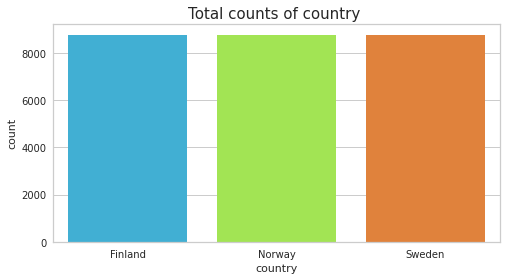

In [25]:
plt.figure(figsize=(8, 4))
sns.countplot(x='country', data=train, order=train["country"].value_counts().index[:3],palette = "turbo")
plt.title("Total counts of country ", size=15)
plt.show()

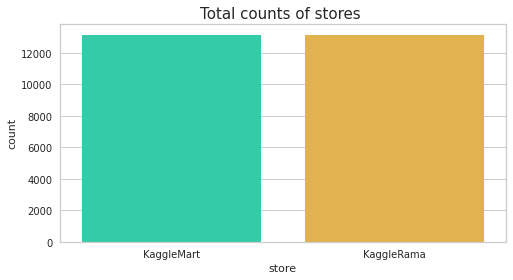

In [26]:
plt.figure(figsize=(8, 4))
sns.countplot(x='store', data=train, order=train["store"].value_counts().index[:2],palette = "turbo")
plt.title("Total counts of stores ", size=15)
plt.show()

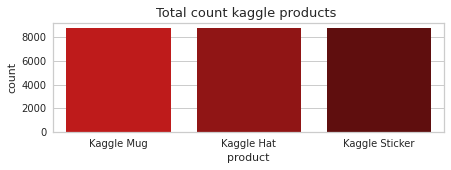

In [27]:
plt.figure(figsize=(7,2))
sns.countplot(x='product', data=train, order=train["product"].value_counts().index[:3],palette = "flag")
plt.title("Total count kaggle products ", size=13)
plt.show()

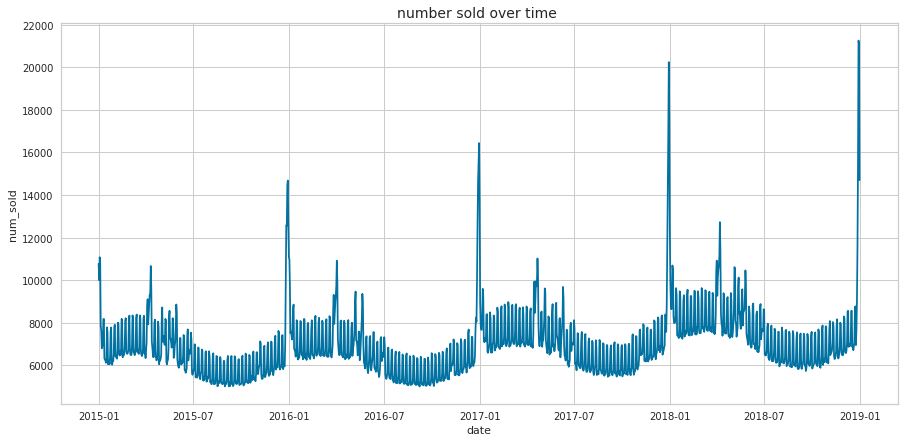

In [28]:
train['date'] = pd.to_datetime(train['date'], format='%Y/%m/%d')
plt.figure(figsize=(15,7))
sld_time = train.groupby(['date']).sum().reset_index()
sns.lineplot(x=sld_time.date, y=sld_time.num_sold,)
plt.title('number sold over time ', fontsize=14)
plt.show()

In [29]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
country_daily = train.groupby(['date','country'])[['num_sold']].sum().reset_index(level=[0,1])
for country in train['country'].unique():
    display(country_daily[country_daily['country']==country].sort_values(by=['num_sold'], ascending=False).head(30))

,date,country,num_sold
4374,2018-12-29,Finland,6029
4377,2018-12-30,Finland,5869
3282,2017-12-30,Finland,5611
3285,2017-12-31,Finland,4683
3279,2017-12-29,Finland,4650
2190,2016-12-31,Finland,4414
4371,2018-12-28,Finland,4287
2187,2016-12-30,Finland,4251
2184,2016-12-29,Finland,3953
4380,2018-12-31,Finland,3951


,date,country,num_sold
4378,2018-12-30,Norway,8980
4375,2018-12-29,Norway,8855
3283,2017-12-30,Norway,8388
3286,2017-12-31,Norway,7433
3280,2017-12-29,Norway,7018
2191,2016-12-31,Norway,6854
4372,2018-12-28,Norway,6427
1090,2015-12-30,Norway,6381
2188,2016-12-30,Norway,6380
4381,2018-12-31,Norway,6275


,date,country,num_sold
4376,2018-12-29,Sweden,6377
3284,2017-12-30,Sweden,6248
4379,2018-12-30,Sweden,6227
3287,2017-12-31,Sweden,5488
3281,2017-12-29,Sweden,5205
2192,2016-12-31,Sweden,5173
2189,2016-12-30,Sweden,4945
2186,2016-12-29,Sweden,4734
4373,2018-12-28,Sweden,4660
1088,2015-12-29,Sweden,4603


#### Grouping by month makes it easier to see overall trends. You can see the trend of peaking at the beginning and end of the year and decreasing before and after.
#### (월별로 그룹화하면 전반적인 추세를 더 쉽게 볼 수 있습니다. 
####  연초와 연말에 정점을 찍고 전후로 감소하는 추세를 볼 수 있습니다.)

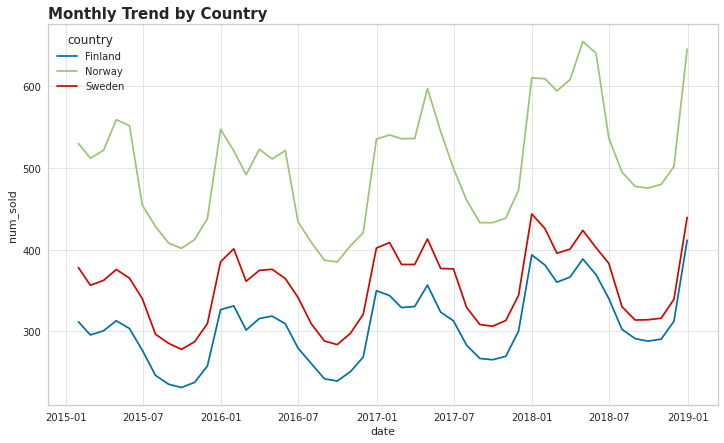

In [30]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
train_monthly_country = train.set_index('date').groupby([pd.Grouper(freq='M'),'country'])[['num_sold']].mean()
sns.lineplot(x="date", y='num_sold', hue='country', data=train_monthly_country, ax=ax)

ax.set_ylabel('num_sold')
ax.set_title('Monthly Trend by Country', fontsize=15, fontweight='bold', loc='left')
ax.grid(alpha=0.5)
plt.show()

#### Day of Week (요일)
#### Time-series data, such as product sales, often have different distributions on weekends and weekdays. Using the day of the week as a feature is often very effective.
#### (제품 판매와 같은 시계열 데이터는 종종 주말과 주중의 분포가 다릅니다. 요일을 기능으로 사용하면 종종 매우 효과적입니다.)

In [31]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
train['dayofweek'] = train['date'].dt.dayofweek
test['dayofweek'] = test['date'].dt.dayofweek

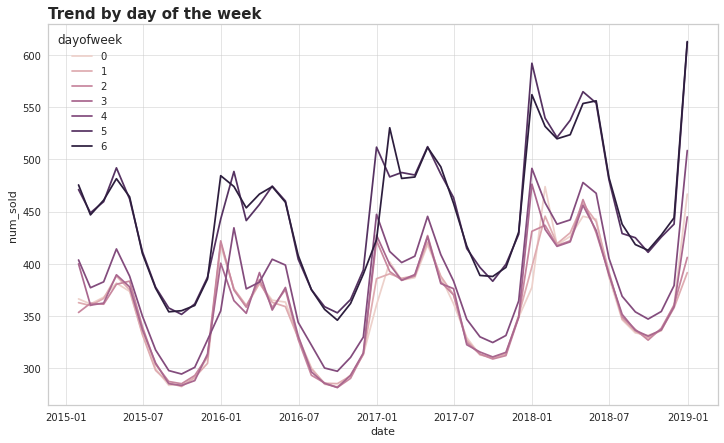

In [32]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
train_dayofweek = train.set_index('date').groupby([pd.Grouper(freq='M'), 'dayofweek'])[['num_sold']].mean()

sns.lineplot(x="date", y='num_sold', hue='dayofweek', data=train_dayofweek, ax=ax)
ax.set_title('Trend by day of the week', fontsize=15, fontweight='bold', loc='left')
ax.grid(alpha=0.5)
plt.show()

#### The following is a comparison by creating a weekend column in more detail.
#### (다음은 주말 칼럼을 보다 구체적으로 생성하여 비교한 것이다.)

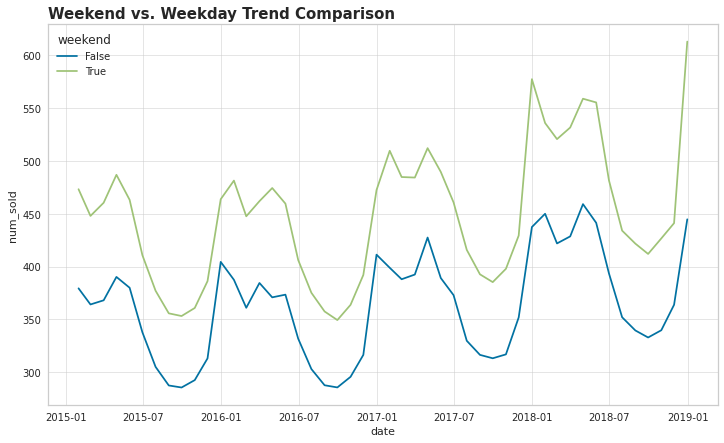

In [33]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
train['weekend'] = train['dayofweek'].apply(lambda x : x >= 5)
fig, ax = plt.subplots(1, 1, figsize=(12, 7))
train_weekend = train.set_index('date').groupby([pd.Grouper(freq='M'), 'weekend'])[['num_sold']].mean()
sns.lineplot(x="date", y="num_sold", hue='weekend', data=train_weekend, ax=ax)
ax.set_title('Weekend vs. Weekday Trend Comparison', fontsize=15, fontweight='bold', loc='left')
ax.grid(alpha=0.5)
plt.show()

In [34]:
country_dayofweek = pd.pivot_table(train, index='country', columns='dayofweek', values='num_sold', aggfunc=np.mean)
country_dayofweek = pd.DataFrame(country_dayofweek.divide(country_dayofweek.sum(axis=1), axis=0).unstack()).reset_index(level=[0,1])
country_dayofweek.rename(columns={0:'num_sold'}, inplace=True)
country_dayofweek

,dayofweek,country,num_sold
0,0,Finland,0.131726
1,0,Norway,0.132270
2,0,Sweden,0.131658
3,1,Finland,0.131869
4,1,Norway,0.131490
5,1,Sweden,0.131453
6,2,Finland,0.132289
7,2,Norway,0.131899
8,2,Sweden,0.132017
9,3,Finland,0.132997


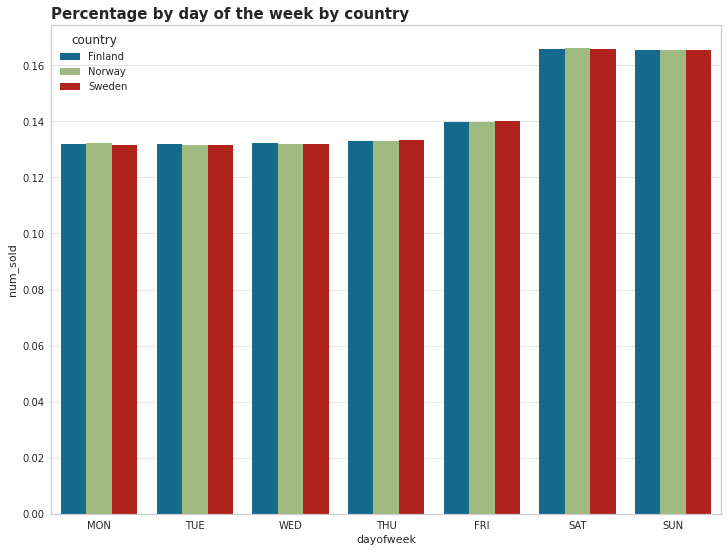

In [35]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
fig, ax = plt.subplots(figsize=(12, 9))
country_dayofweek = pd.pivot_table(train, index='country', columns='dayofweek', values='num_sold', aggfunc=np.mean)
country_dayofweek = pd.DataFrame(country_dayofweek.divide(country_dayofweek.sum(axis=1), axis=0).unstack()).reset_index(level=[0,1])
country_dayofweek.rename(columns={0:'num_sold'}, inplace=True)
# country_dayofweek.reset_index(level=[0,1])
sns.barplot(x='dayofweek', y='num_sold', hue='country',data=country_dayofweek, ax=ax)
ax.grid(axis='y',alpha=0.5, )
ax.set_xticklabels(['MON', 'TUE', 'WED','THU','FRI','SAT','SUN'])
ax.set_title('Percentage by day of the week by country', fontsize=15, fontweight='bold', loc='left')
plt.show()

#### You can see that Friday has a higher percentage compared to other days of the week.
#### (금요일에는 다른 요일에 비해 비율이 높은 것을 알 수 있습니다.)

#### Pivot (etc) (피벗(기타))
####  ▶ product ratio by country  (국가별 제품 비율)
#### You can check the following to see if there is a preference for each country, and there does not seem to be a significant difference.
#### (국가별 선호도가 있는지는 다음과 같이 확인할 수 있으며, 큰 차이는 없어 보입니다.)

In [36]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
country_product = pd.pivot_table(train, index='country', columns='product', values='num_sold', aggfunc=np.mean)
country_product.divide(country_product.sum(axis=1), axis=0)

product,Kaggle Hat,Kaggle Mug,Kaggle Sticker
country,,,
Finland,0.540278,0.305348,0.154375
Norway,0.540989,0.304714,0.154298
Sweden,0.541298,0.304437,0.154264


#### You can check the following to see if there is a preference for each day of week, and there does not seem to be a significant difference.
#### (요일별 선호도가 있는지 다음과 같이 확인할 수 있으며, 큰 차이는 없어 보입니다.)

In [37]:
# Code Source : https://www.kaggle.com/subinium/tps-jan-happy-new-year
country_product_dayofweek = pd.pivot_table(train, index='dayofweek', columns='product', values='num_sold', aggfunc=np.mean)
country_product_dayofweek.divide(country_product_dayofweek.sum(axis=1), axis=0)

product,Kaggle Hat,Kaggle Mug,Kaggle Sticker
dayofweek,,,
0,0.540618,0.305092,0.154290
1,0.540861,0.304648,0.154491
2,0.541073,0.304628,0.154299
3,0.541214,0.304677,0.154108
4,0.540796,0.304549,0.154655
5,0.540148,0.305577,0.154275
6,0.541584,0.304332,0.154083


In [38]:
# Code Sorce : https://www.kaggle.com/bernhardklinger/tps-jan-2022
def pre_process(df):
    
    df['date'] = pd.to_datetime(df['date'])
    df['week']= df['date'].dt.week
    df['year'] = 'Y'+df['date'].dt.year.astype(str)
    df['quarter'] = 'Q'+df['date'].dt.quarter.astype(str)
    df['day'] = df['date'].dt.day
    df['dayofyear'] = df['date'].dt.dayofyear
    df.loc[(df.date.dt.is_leap_year) & (df.dayofyear >= 60),'dayofyear'] -= 1
    df['weekend'] = df['date'].dt.weekday >=5
    df['weekday'] = 'WD' + df['date'].dt.weekday.astype(str)
    df.drop(columns=['date'],inplace=True)   

pre_process(train)
pre_process(test)

In [39]:
# Code Sorce : https://www.kaggle.com/bernhardklinger/tps-jan-2022
train.info(), test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26298 entries, 0 to 26297
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   country    26298 non-null  object
 1   store      26298 non-null  object
 2   product    26298 non-null  object
 3   num_sold   26298 non-null  int64 
 4   dayofweek  26298 non-null  int64 
 5   weekend    26298 non-null  bool  
 6   week       26298 non-null  int64 
 7   year       26298 non-null  object
 8   quarter    26298 non-null  object
 9   day        26298 non-null  int64 
 10  dayofyear  26298 non-null  int64 
 11  weekday    26298 non-null  object
dtypes: bool(1), int64(5), object(6)
memory usage: 3.4+ MB
<class 'pandas.core.frame.DataFrame'>
Int64Index: 6570 entries, 26298 to 32867
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   country    6570 non-null   object
 1   store      6570 non-null   object
 2   product    65

(None, None)

# Modeling (모델링)

#### Code to calculate the 'time series data' of the second place in the 'Web Traffic Time Series Prediction' contest held in Kaggle 4 years ago
#### (4년전 캐글에서 열린 '웹 트래픽 시계열 예측' 대회에서 2등을 한 사람의 '시계열 데이터'를 계산하는 코드)

In [40]:
# Code sorce : https://www.kaggle.com/c/web-traffic-time-series-forecasting/discussion/36414
def SMAPE(y_true, y_pred):
    denominator = (y_true + np.abs(y_pred)) / 200.0
    diff = np.abs(y_true - y_pred) / denominator
    diff[denominator == 0] = 0.0
    return np.mean(diff)

In [41]:
reg = setup(data = train,
            target = 'num_sold',
            normalize=True,
            normalize_method='robust',
            transform_target = True,
            data_split_shuffle = False, 
            create_clusters = False,
            use_gpu = True,
            silent = True,
            fold=10,
            n_jobs = -1)

,Description,Value
0,session_id,1256
1,Target,num_sold
2,Original Data,"(26298, 12)"
3,Missing Values,False
4,Numeric Features,3
5,Categorical Features,8
6,Ordinal Features,False
7,High Cardinality Features,False
8,High Cardinality Method,None
9,Transformed Train Set,"(18408, 25)"


In [42]:
# Code Sorce : https://www.kaggle.com/bernhardklinger/tps-jan-2022
add_metric('SMAPE', 'SMAPE', SMAPE, greater_is_better = False)
top =compare_models(sort = 'SMAPE',n_select = 3, include = ['catboost','lightgbm','xgboost']) 

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,SMAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,26.4778,2476.0365,46.4348,0.9653,0.0912,0.0670,6.6983,1.0440
catboost,CatBoost Regressor,27.4563,3036.9175,49.7696,0.9589,0.0947,0.0679,6.7530,2.8350
xgboost,Extreme Gradient Boosting,27.0547,2557.9026,47.0485,0.9643,0.0942,0.0682,6.8439,0.4410


In [43]:
best_models = compare_models(top)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,SMAPE,TT (Sec)
0,Light Gradient Boosting Machine,26.5439,2487.1471,46.5142,0.9652,0.0915,0.0671,6.7180,0.4970
2,Extreme Gradient Boosting,27.0547,2557.9026,47.0485,0.9643,0.0942,0.0682,6.8439,0.3730
1,CatBoost Regressor,27.4563,3036.9175,49.7696,0.9589,0.0947,0.0679,6.7530,2.8350


In [44]:
# Code Sorce : https://www.kaggle.com/bernhardklinger/tps-jan-2022
blend = blend_models(top)
predict_model(blend)

,MAE,MSE,RMSE,R2,RMSLE,MAPE,SMAPE
0,30.0974,3187.3524,56.4566,0.9601,0.1014,0.0690,7.0693
1,35.4112,2911.4366,53.9577,0.9579,0.1162,0.1002,9.3873
2,13.9867,413.6943,20.3395,0.9870,0.0558,0.0453,4.4456
3,27.8423,2582.1833,50.8152,0.9619,0.1019,0.0708,6.6853
4,34.4194,4221.2063,64.9708,0.9491,0.1145,0.0777,8.0964
5,19.8335,1007.8525,31.7467,0.9770,0.0737,0.0598,5.7670
6,14.5810,444.0523,21.0725,0.9860,0.0581,0.0453,4.5424
7,33.7929,5585.3312,74.7351,0.9371,0.1127,0.0650,6.9509
8,34.4807,4201.7844,64.8212,0.9525,0.1139,0.0753,7.9423
9,15.3415,486.8727,22.0652,0.9873,0.0550,0.0442,4.4627


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,SMAPE
0,Voting Regressor,42.5749,5527.1179,74.3446,0.9348,0.1192,0.0881,9.3742


,week,day,dayofyear,country_Finland,country_Norway,country_Sweden,store_KaggleRama,product_Kaggle Hat,product_Kaggle Mug,product_Kaggle Sticker,...,quarter_Q1,quarter_Q2,quarter_Q3,quarter_Q4,weekday_WD0,weekday_WD1,weekday_WD3,weekday_WD6,num_sold,Label
0,0.708333,0.2,0.707602,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,223,223.599741
1,0.708333,0.2,0.707602,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,303,301.143469
2,0.708333,0.2,0.707602,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,112,109.308410
3,0.708333,0.2,0.707602,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,419,385.684089
4,0.708333,0.2,0.707602,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,550,524.650568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7885,-1.000000,1.0,1.134503,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,823,648.333201
7886,-1.000000,1.0,1.134503,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,250,219.045871
7887,-1.000000,1.0,1.134503,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1004,753.086341
7888,-1.000000,1.0,1.134503,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1441,1189.189096


In [45]:
# Code Sorce : https://www.kaggle.com/bernhardklinger/tps-jan-2022
final_blend = finalize_model(blend)  
predict_model(final_blend)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,SMAPE
0,Voting Regressor,20.7013,1067.2105,32.6682,0.9874,0.0605,0.0475,4.8403


,week,day,dayofyear,country_Finland,country_Norway,country_Sweden,store_KaggleRama,product_Kaggle Hat,product_Kaggle Mug,product_Kaggle Sticker,...,quarter_Q1,quarter_Q2,quarter_Q3,quarter_Q4,weekday_WD0,weekday_WD1,weekday_WD3,weekday_WD6,num_sold,Label
0,0.708333,0.2,0.707602,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,223,225.670747
1,0.708333,0.2,0.707602,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,303,304.633516
2,0.708333,0.2,0.707602,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,112,110.237661
3,0.708333,0.2,0.707602,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,419,392.953237
4,0.708333,0.2,0.707602,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,550,531.769134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7885,-1.000000,1.0,1.134503,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,823,842.107813
7886,-1.000000,1.0,1.134503,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,250,254.266953
7887,-1.000000,1.0,1.134503,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1004,957.357321
7888,-1.000000,1.0,1.134503,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1441,1422.996849


In [46]:
# Code Sorce : https://www.kaggle.com/bernhardklinger/tps-jan-2022
preds = predict_model(final_blend, data=test) 
sub = pd.DataFrame(list(zip(test.index,preds.Label)),columns = ['row_id', 'num_sold']) 
sub.to_csv('submission.csv', index = False) 
print(sub.head(),sub.describe())

   row_id    num_sold
0   26298  385.076906
1   26299  586.455865
2   26300  165.921560
3   26301  656.086402
4   26302  996.272651              row_id     num_sold
count   6570.000000  6570.000000
mean   29582.500000   410.390106
std     1896.739966   277.224519
min    26298.000000    96.117375
25%    27940.250000   201.661353
50%    29582.500000   339.755171
75%    31224.750000   536.487421
max    32867.000000  2822.059314


In [47]:
test.head()

,country,store,product,dayofweek,week,year,quarter,day,dayofyear,weekend,weekday
row_id,,,,,,,,,,,
26298,Finland,KaggleMart,Kaggle Mug,1,1,Y2019,Q1,1,1,False,WD1
26299,Finland,KaggleMart,Kaggle Hat,1,1,Y2019,Q1,1,1,False,WD1
26300,Finland,KaggleMart,Kaggle Sticker,1,1,Y2019,Q1,1,1,False,WD1
26301,Finland,KaggleRama,Kaggle Mug,1,1,Y2019,Q1,1,1,False,WD1
26302,Finland,KaggleRama,Kaggle Hat,1,1,Y2019,Q1,1,1,False,WD1


In [48]:
train.head()

,country,store,product,num_sold,dayofweek,weekend,week,year,quarter,day,dayofyear,weekday
row_id,,,,,,,,,,,,
0,Finland,KaggleMart,Kaggle Mug,329,3,False,1,Y2015,Q1,1,1,WD3
1,Finland,KaggleMart,Kaggle Hat,520,3,False,1,Y2015,Q1,1,1,WD3
2,Finland,KaggleMart,Kaggle Sticker,146,3,False,1,Y2015,Q1,1,1,WD3
3,Finland,KaggleRama,Kaggle Mug,572,3,False,1,Y2015,Q1,1,1,WD3
4,Finland,KaggleRama,Kaggle Hat,911,3,False,1,Y2015,Q1,1,1,WD3
